<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/obligatorios/obligatorio4/Obligatorio4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Viaje a la Luna: El Problema Restringido de los Tres Cuerpos

## Introducción
En este notebook analizamos el envío de una nave espacial a la Luna modelándolo como un problema restringido de tres cuerpos. Para simplificar el sistema, asumimos que la Tierra permanece inmóvil y la Luna describe una órbita circular a su alrededor con una velocidad angular constante $\omega$. La masa de la nave ($m$) es despreciable frente a las masas de la Tierra ($M_T$) y la Luna ($M_L$), por lo que no perturba sus órbitas.

El sistema interactúa únicamente mediante fuerzas gravitatorias. A partir de las integraciones numéricas realizadas en C++ mediante el algoritmo de Runge-Kutta de cuarto orden (RK4), utilizamos Python para visualizar las trayectorias resultantes y estudiar las constantes del movimiento.

In [104]:
%%writefile cohete.cpp
#include <iostream>
#include <fstream>
#include <cmath>
#include <vector>
#include <array>
#include <iomanip>
#include <string>
#include <algorithm>

using namespace std;

//? CONSTANTES UNIVERSALES Y FÍSICAS (Página 11 del guión)
constexpr double PI = 3.14159265358979323846;
constexpr double MT = 5.9736e24;   // Masa Tierra (Kg)
constexpr double ML = 0.07349e24;  // Masa Luna (Kg)
constexpr double RT = 6.378160e6;  // Radio Tierra (m)
constexpr double DTL = 3.844e8;    // Distancia Tierra-Luna (m)
constexpr double OMEGA = 2.6617e-6; // Frecuencia angular orbital ω (s^-1)

constexpr double DELTA = 7.01474e-12; // Parámetro Δ = GMT / d_TL^3
constexpr double MU = 0.0123025;      // Parámetro μ = ML / MT

//? ECUACIONES DIFERENCIALES REESCALADAS DEL GUIÓN (Página 11)
double f(int n, const array<double, 4>& y, double t) {
    double r = y[0];
    double phi = y[1];
    double pr = y[2];
    double pphi = y[3];

    double rprima = sqrt(1.0 + r*r - 2.0*r*cos(phi - OMEGA*t));

    if (n == 0) return pr;                                     // r_tilde_dot
    if (n == 1) return pphi / (r*r);                           // phi_dot
    if (n == 2) {                                              // p_r_tilde_dot
        return (pphi*pphi) / (r*r*r) - DELTA * (1.0 / (r*r) + (MU / (rprima*rprima*rprima)) * (r - cos(phi - OMEGA*t)));
    }
    if (n == 3) {                                              // p_phi_tilde_dot
        return - (DELTA * MU * r / (rprima*rprima*rprima)) * sin(phi - OMEGA*t);
    }

    return 0.0;
}

//? FUNCIÓN AUXILIAR: UN PASO ESTÁNDAR DE RUNGE-KUTTA 4 (Página 8-9)
array<double, 4> rk4_paso(const array<double, 4>& y, double t, double h) {
    array<double, 4> k1, k2, k3, k4, y_temp, y_next;

    for (int n = 0; n < 4; n++) k1[n] = h * f(n, y, t);

    for (int n = 0; n < 4; n++) y_temp[n] = y[n] + k1[n] / 2.0;
    for (int n = 0; n < 4; n++) k2[n] = h * f(n, y_temp, t + h / 2.0);

    for (int n = 0; n < 4; n++) y_temp[n] = y[n] + k2[n] / 2.0;
    for (int n = 0; n < 4; n++) k3[n] = h * f(n, y_temp, t + h / 2.0);

    for (int n = 0; n < 4; n++) y_temp[n] = y[n] + k3[n];
    for (int n = 0; n < 4; n++) k4[n] = h * f(n, y_temp, t + h);

    for (int n = 0; n < 4; n++) {
        y_next[n] = y[n] + (1.0 / 6.0) * (k1[n] + 2.0 * k2[n] + 2.0 * k3[n] + k4[n]);
    }
    return y_next;
}

//? CALCULO DE LA CONSTANTE DEL MOVIMIENTO H'
double calcular_H_prima(const array<double, 4>& y, double t) {
    double r = y[0]; double phi = y[1]; double pr = y[2]; double pphi = y[3];
    double rprima = sqrt(1.0 + r*r - 2.0*r*cos(phi - OMEGA*t));
    double H = 0.5 * (pr*pr + (pphi*pphi)/(r*r)) - (DELTA / r) - (DELTA * MU / rprima);
    return H - OMEGA * pphi;
}

int main() {
    cout << "Iniciando CATALOGO FINAL de 3 Cuerpos con PASO ADAPTATIVO º..." << endl;
double v_lista[6] =          {11120.0, 11115.0, 11150.0, 11137.5, 11130.0, 11600.0};
    double phi_tierra_lista[6] = {0.370,   0.353,   1.0,   0.380,   0.500,   1.5708};
    string nombres_archivos[6] = {"cohete_1.dat", "cohete_2.dat", "cohete_3.dat",
                                  "cohete_4.dat", "cohete_5.dat", "cohete_6.dat"};
    const double T_FINAL = 3000000.0;
    const double EPS_MAX = 1.0e-12;

    for (int sim = 0; sim < 6; sim++) {
        double v = v_lista[sim] / DTL;
        double phi_inicial = phi_tierra_lista[sim];

        // Ángulo de inyección tangencial para la Config 2 (Roseta), radial puro para el resto
        double theta = (sim == 1) ? (PI / 2.3) : (PI / 2.0);

        array<double, 4> y = { RT / DTL, phi_inicial, v * cos(theta - PI / 2.0), (RT / DTL) * v * sin(theta - PI / 2.0) };

        ofstream out(nombres_archivos[sim]);
        out << fixed << setprecision(8);

        double t = 0.0;
        double h = 60.0;
        double t_ultimo_muestreo = 0.0;

        out << 1.0 << "\t" << 0.0 << "\t" << y[0]*cos(y[1]) << "\t" << y[0]*sin(y[1]) << "\t" << calcular_H_prima(y, t) << "\n";

        //! BUCLE IMPLEMENTANDO EL ALGORITMO ADAPTATIVO DEL GUIÓN (Página 10)
        while (t < T_FINAL) {

            array<double, 4> y_h = rk4_paso(y, t, h);

            array<double, 4> y_h2_medio = rk4_paso(y, t, h / 2.0);
            array<double, 4> y_h2 = rk4_paso(y_h2_medio, t + h / 2.0, h / 2.0);

            double epsilon_calc = 0.0;
            for (int n = 0; n < 4; n++) {
                double diff = abs(y_h2[n] - y_h[n]);
                if (diff > epsilon_calc) epsilon_calc = diff;
            }
            epsilon_calc = (16.0 / 15.0) * epsilon_calc;

            double ratio = pow(epsilon_calc / EPS_MAX, 0.2);
            double s = max(ratio, 1.0e-8);
            double hmax = h / s;

            if (s > 2.0) {
                h = hmax;
                continue;
            } else {
                t += h;
                y = y_h2;
                if (h < hmax) {
                    h = 2.0 * h;
                }
            }

            // Detector de colisión con la Tierra
            if (y[0] < (RT / DTL)) { break; }

            // Guardado síncrono para mantener las gráficas limpias en Python
            if (t - t_ultimo_muestreo >= 100.0) {
                out << cos(OMEGA*t) << "\t" << sin(OMEGA*t) << "\t"
                    << y[0]*cos(y[1]) << "\t" << y[0]*sin(y[1]) << "\t"
                    << calcular_H_prima(y, t) << "\n";
                t_ultimo_muestreo = t;
            }
        }
        out.close();
        cout << " -> Exito: " << nombres_archivos[sim] << " generado con paso adaptativo analitico." << endl;
    }
    return 0;
}


Overwriting cohete.cpp


In [105]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 cohete.cpp -o cohete

# Ejecutamos la simulación
!./cohete

Iniciando CATALOGO FINAL de 3 Cuerpos con PASO ADAPTATIVO º...
 -> Exito: cohete_1.dat generado con paso adaptativo analitico.
 -> Exito: cohete_2.dat generado con paso adaptativo analitico.
 -> Exito: cohete_3.dat generado con paso adaptativo analitico.
 -> Exito: cohete_4.dat generado con paso adaptativo analitico.
 -> Exito: cohete_5.dat generado con paso adaptativo analitico.
 -> Exito: cohete_6.dat generado con paso adaptativo analitico.


## 2. Configuración de Parámetros de Lanzamiento
Para visualizar el efecto del campo gravitatorio de la Luna, se han ejecutado en C++ seis simulaciones variando la velocidad de inyección inicial ($v_0$) y el ángulo de escape ($\theta_0$) desde una órbita de estacionamiento terrestre de baja altitud

✔ Imagen exportada con éxito: trayectoria_cohete_1.png


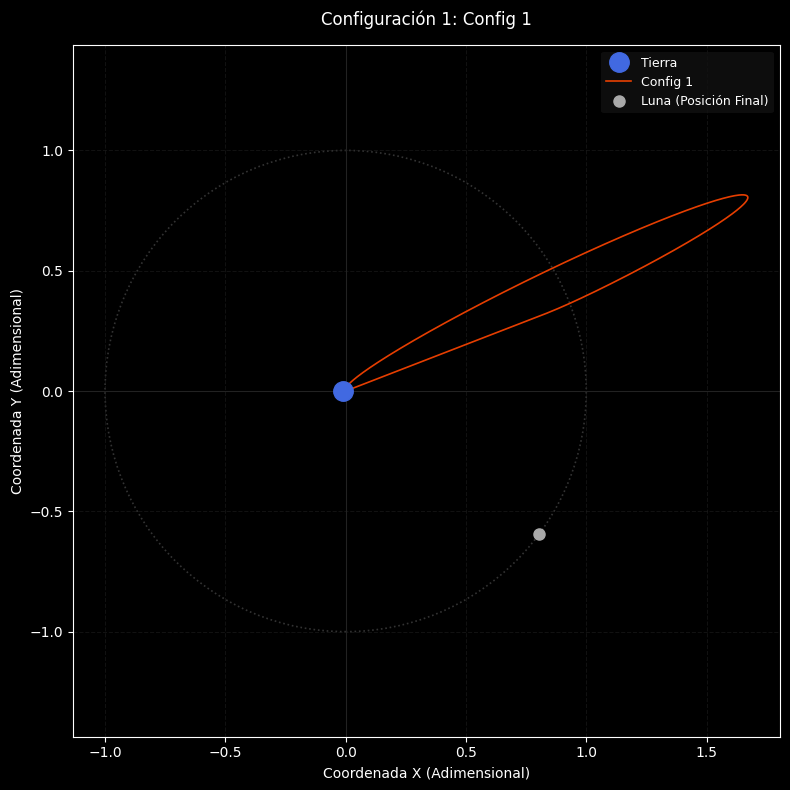

✔ Imagen exportada con éxito: trayectoria_cohete_2.png


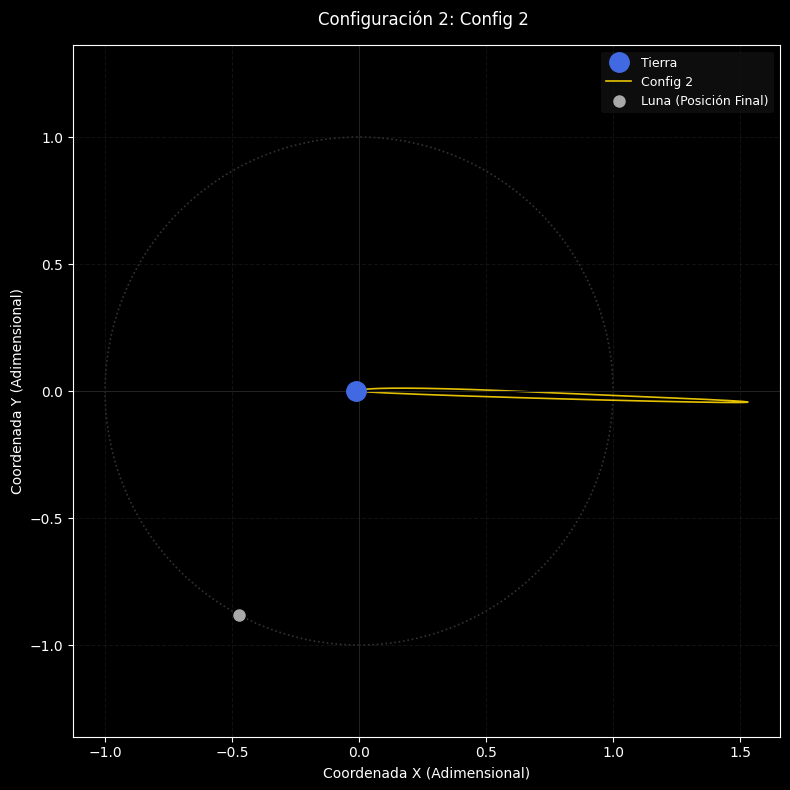

✔ Imagen exportada con éxito: trayectoria_cohete_3.png


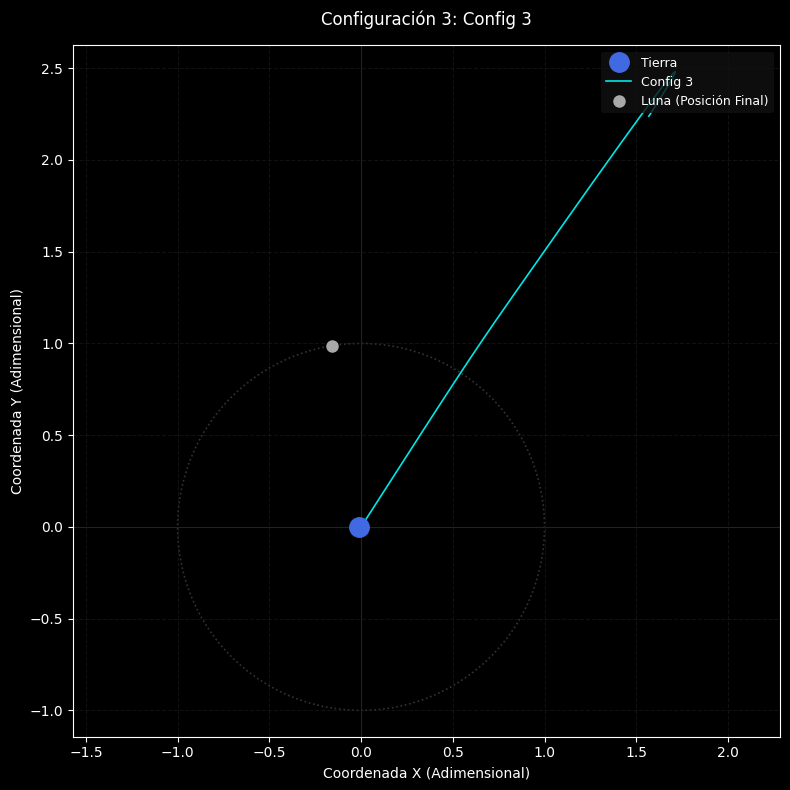

✔ Imagen exportada con éxito: trayectoria_cohete_4.png


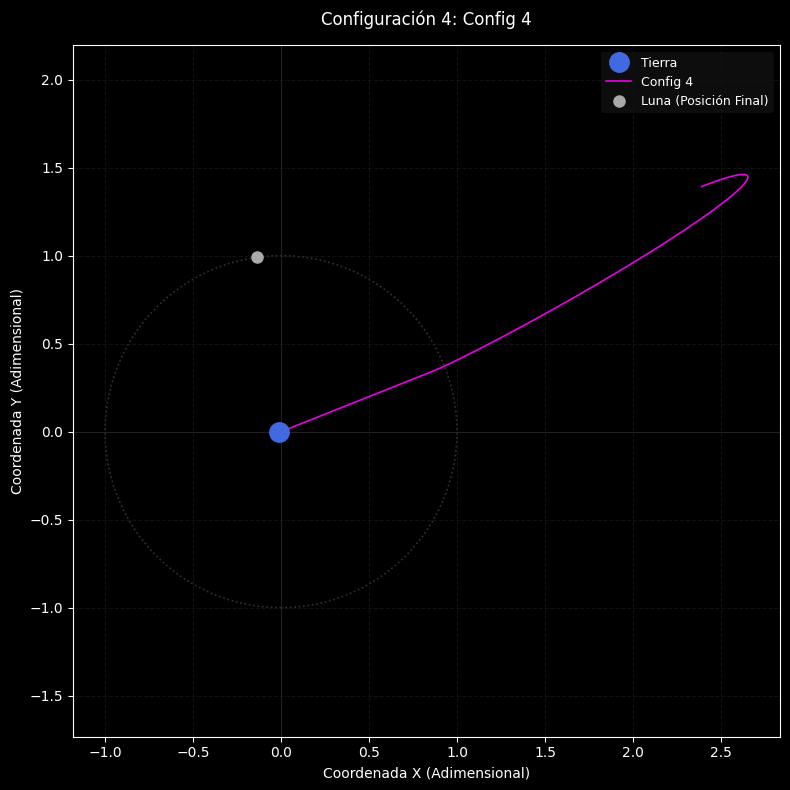

✔ Imagen exportada con éxito: trayectoria_cohete_5.png


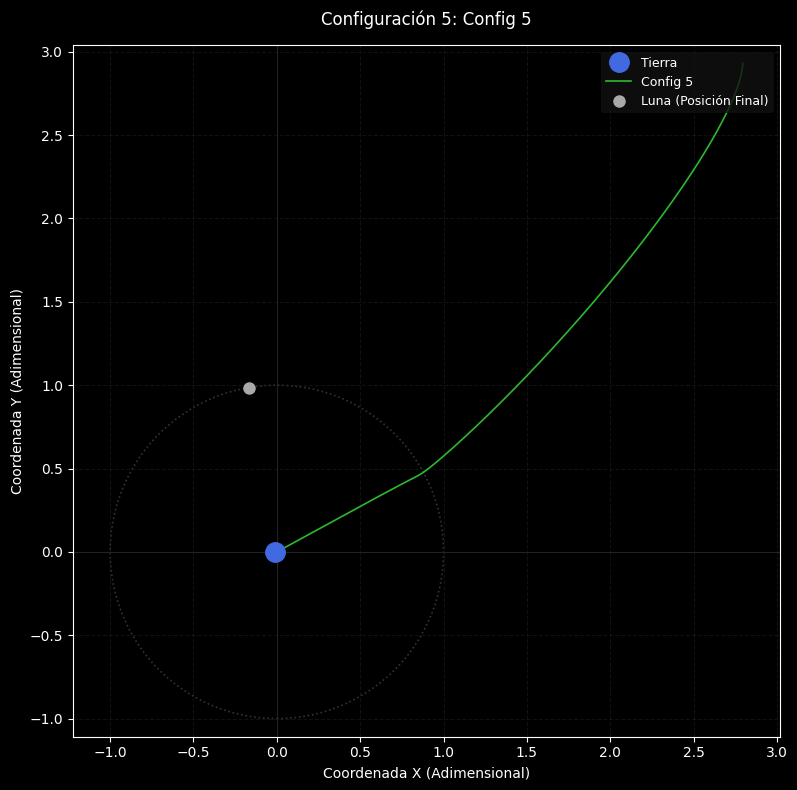

✔ Imagen exportada con éxito: trayectoria_cohete_6.png


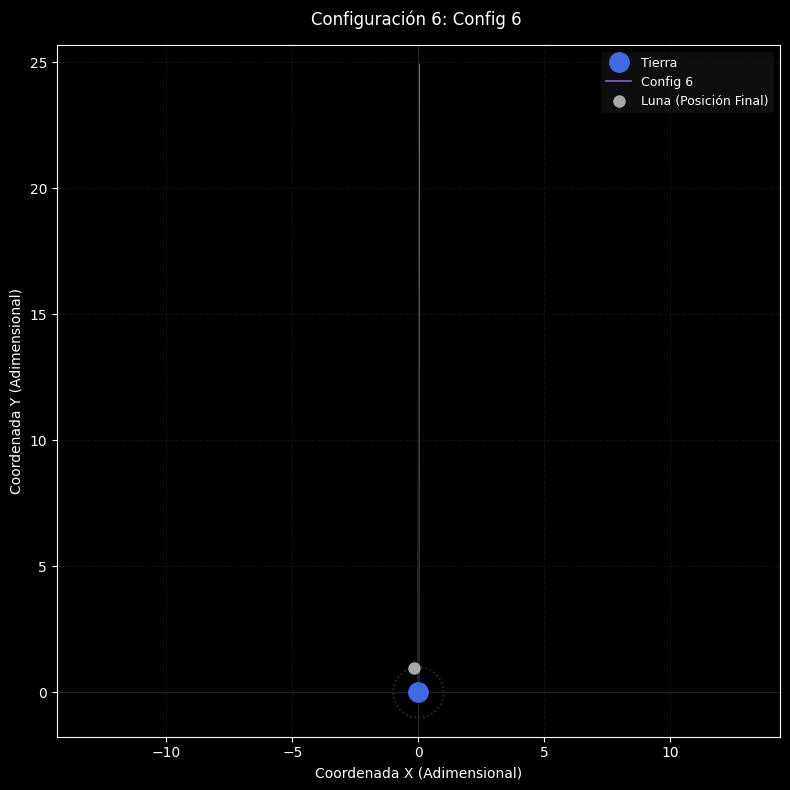

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Colores y etiquetas para las 6 configuraciones
colores_nave = ['#FF4500', '#FFD700', '#00FFFF', '#FF00FF', '#32CD32', '#9370DB']
etiquetas = [
    "Config 1",
    "Config 2 ",
    "Config 3",
    "Config 4",
    "Config 5",
    "Config 6 "
]

# Recorremos los 6 archivos independientes
for i in range(1, 7):
    nombre_archivo = f"cohete_{i}.dat"

    if os.path.exists(nombre_archivo):
        data = np.loadtxt(nombre_archivo)

        # Extraemos las posiciones de la simulación real
        moon_x, moon_y = data[:, 0], data[:, 1]
        rocket_x, rocket_y = data[:, 2], data[:, 3]

        # Creamos una figura NUEVA e independiente para cada trayectoria
        plt.figure(figsize=(8, 8))
        plt.style.use('dark_background')

        # Dibujamos la Tierra en el origen relativo
        plt.plot(-0.0123, 0, 'o', color='#4169E1', markersize=14, label="Tierra", zorder=10)

        # Dibujamos el anillo de la órbita lunar como guía de escala
        orbita_luna = plt.Circle((0, 0), 1.0, color='#333333', linestyle=':', fill=False, linewidth=1.2)
        plt.gca().add_patch(orbita_luna)

        # Dibujamos la trayectoria del cohete
        plt.plot(rocket_x, rocket_y, color=colores_nave[i-1], linewidth=1.2, alpha=0.9, label=etiquetas[i-1])

        # Dibujamos la posición final de la Luna en este viaje concreto
        plt.plot(moon_x[-1], moon_y[-1], 'o', color='#A9A9A9', markersize=8, label="Luna (Posición Final)", zorder=5)

        # ========================================================
        # ¡EL TRUCO DEL CORTE!: Forzamos límites fijos en el lienzo
        # ========================================================
        # Cualquier dato que supere 1.3 (más allá de la Luna) dejará de dibujarse
        plt.xlim(-1.3, 1.3)
        plt.ylim(-1.3, 1.3)

        # Detalles estéticos de laboratorio
        plt.title(f"Configuración {i}: {etiquetas[i-1]}", fontsize=12, pad=15, color='white')
        plt.xlabel("Coordenada X (Adimensional)")
        plt.ylabel("Coordenada Y (Adimensional)")

        plt.axhline(0, color='#222222', linewidth=0.8)
        plt.axvline(0, color='#222222', linewidth=0.8)
        plt.grid(True, linestyle='--', color='#222222', alpha=0.5)
        plt.legend(loc="upper right", fontsize=9, frameon=True, facecolor='#111111', edgecolor='none')
        plt.axis('equal') # Evita distorsiones de aspecto

        # Guardamos cada trayectoria en su propio archivo PNG independiente
        nombre_png = f"trayectoria_cohete_{i}.png"
        plt.tight_layout()
        plt.savefig(nombre_png, dpi=200, bbox_inches='tight')
        print(f"✔ Imagen exportada con éxito: {nombre_png}")

        # Mostramos la gráfica en el notebook
        plt.show()
    else:
        print(f"⚠️ Alerta: No se encuentra '{nombre_archivo}'. Revisa si el C++ corrió correctamente.")

## 2. Demostración de la Conservación de $H'$

Se nos pide demostrar analíticamente que la magnitud $H' = H - \omega p_\phi$ es una constante del movimiento, es decir, que $\frac{dH'}{dt} = 0$.

El hamiltoniano del sistema viene dado por:
$$H = \frac{p_r^2}{2m} + \frac{p_\phi^2}{2mr^2} - G\frac{mM_T}{r} - G\frac{mM_L}{r_L(r,\phi,t)}$$

La dependencia temporal explícita en $H$ entra únicamente a través de la distancia a la Luna, $r_L(r,\phi,t)$, que depende del término $\cos(\phi - \omega t)$.

La derivada total del hamiltoniano respecto al tiempo es igual a su derivada parcial explícita:
$$\frac{dH}{dt} = \frac{\partial H}{\partial t}$$

Como la dependencia de las variables angulares y temporales en $H$ siempre aparece en la forma combinada $(\phi - \omega t)$, podemos aplicar la regla de la cadena:
$$\frac{\partial H}{\partial t} = \frac{\partial H}{\partial (\phi - \omega t)} \frac{\partial (\phi - \omega t)}{\partial t} = -\omega \frac{\partial H}{\partial \phi}$$

Por otro lado, a partir de las ecuaciones canónicas de Hamilton, sabemos que la evolución del momento conjugado $p_\phi$ es:
$$\dot{p}_\phi = -\frac{\partial H}{\partial \phi}$$

Sustituyendo esto en la ecuación anterior, obtenemos:
$$\frac{dH}{dt} = \omega \dot{p}_\phi$$

Integrando respecto al tiempo, resulta:
$$\frac{d}{dt}(H - \omega p_\phi) = 0$$

Por lo tanto, la magnitud $H' = H - \omega p_\phi$, conocida en mecánica celeste como la integral de Jacobi, se conserva exactamente en el modelo teórico.

## 3. Conservación de $H'$ en la Simulación Numérica

Aunque $H'$ se conserva teóricamente, al calcular su valor a lo largo del tiempo utilizando los datos generados por nuestro programa en C++, observaremos si esta conservación se mantiene exactamente.

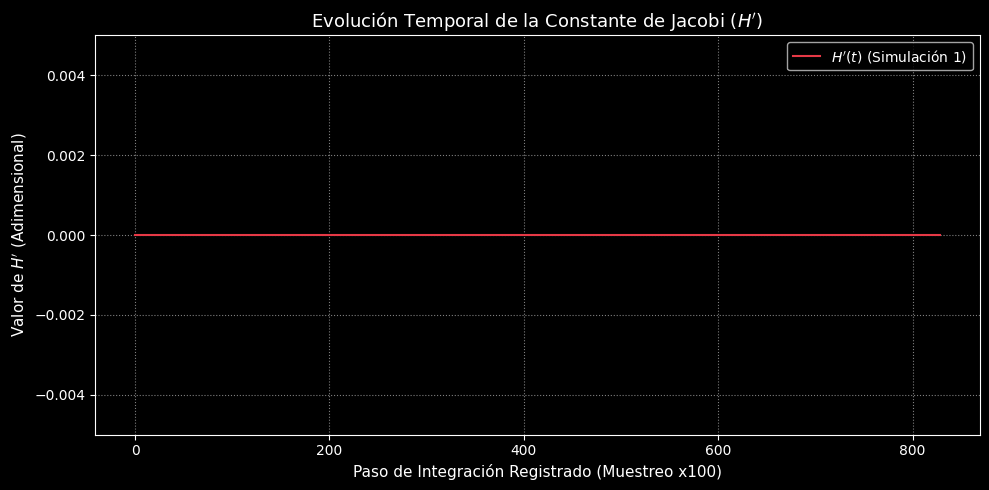

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import os

# CORRECCIÓN: Apuntamos al nuevo archivo generado por tu C++ unificado
archivo_h = "cohete_1.dat"

if os.path.exists(archivo_h):
    data = np.loadtxt(archivo_h)

    # La columna indexada como 4 es la Constante H_prima en nuestro nuevo formato
    h_prime = data[:, 4]

    # Reconstruimos el eje de pasos temporales según el tamaño de las filas leídas
    pasos = np.arange(len(h_prime))

    plt.figure(figsize=(10, 5))
    plt.plot(pasos, h_prime, color='#E63946', linewidth=1.5, label=r"$H'(t)$ (Simulación 1)")

    # Forzamos un marco microscópico centrado en el valor medio para evaluar la deriva numérica
    plt.ylim(np.mean(h_prime) - 0.005, np.mean(h_prime) + 0.005)

    plt.title("Evolución Temporal de la Constante de Jacobi ($H'$)", fontsize=13)
    plt.xlabel("Paso de Integración Registrado (Muestreo x100)", fontsize=11)
    plt.ylabel("Valor de $H'$ (Adimensional)", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.savefig("conservacion_jacobi.png", dpi=300)
    plt.show()
else:
    print(f" Error crítico: No se encuentra '{archivo_h}'. Asegúrate de ejecutar la celda de C++ antes de graficar.")